# Data Exploration

My goal in this notebook is to explore the dataset.  
This notebook is heavily inspired by the data analysis course.

In [34]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.ticker as mticker

## 1. Data Loading

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data/raw"

champs_df = pd.read_csv(DATA_DIR / "champs.csv")
matches_df = pd.read_csv(DATA_DIR / "matches.csv")
participants_df = pd.read_csv(DATA_DIR / "participants.csv")
stats1_df = pd.read_csv(DATA_DIR / "stats1.csv")
stats2_df = pd.read_csv(DATA_DIR / "stats2.csv")
teambans_df = pd.read_csv(DATA_DIR / "teambans.csv")
teamstats_df = pd.read_csv(DATA_DIR / "teamstats.csv")

# NOTE: I merged stats aferwards because they are the same data but split into two files.
stats2_df = stats2_df[stats1_df.columns]
stats_df = pd.concat([stats1_df, stats2_df], axis=0, ignore_index=True)


all_dfs = {
    "champs": champs_df,
    "matches": matches_df,
    "participants": participants_df,
    "stats": stats_df,
    "teambans": teambans_df,
    "teamstats": teamstats_df,
}

/tmp/ipykernel_8213/134812854.py:8: DtypeWarning: Columns (0: wardsbought) have mixed types. Specify dtype option on import or set low_memory=False.
  stats2_df = pd.read_csv(DATA_DIR / "stats2.csv")


In [4]:
for name, df in all_dfs.items():
    print(f"\n{name}:")
    print(f"shape: {df.shape}")
    print(f"dtypes values:\n{df.dtypes.value_counts()}")
    print(f"memory_usage: {df.memory_usage(deep=True).sum() / 1024**2} MB")


champs:
shape: (138, 2)
dtypes values:
str      1
int64    1
Name: count, dtype: int64
memory_usage: 0.00843048095703125 MB

matches:
shape: (184069, 8)
dtypes values:
int64    6
str      2
Name: count, dtype: int64
memory_usage: 28.42035484313965 MB

participants:
shape: (1834520, 8)
dtypes values:
int64    6
str      2
Name: count, dtype: int64
memory_usage: 272.57017517089844 MB

stats:
shape: (1834517, 56)
dtypes values:
int64     55
object     1
Name: count, dtype: int64
memory_usage: 838.8466444015503 MB

teambans:
shape: (1099185, 4)
dtypes values:
int64    4
Name: count, dtype: int64
memory_usage: 33.54458999633789 MB

teamstats:
shape: (368138, 13)
dtypes values:
int64    13
Name: count, dtype: int64
memory_usage: 36.51283645629883 MB


## 2. Schema Overview

In [5]:
def sample_values(series, n=3):
    vals = series.dropna().astype(str).unique()[:n]
    return ", ".join(vals) if len(vals) else "(all missing)"

schema_rows = []

for table_name, df in all_dfs.items():
    for col in df.columns:
        s = df[col]
        schema_rows.append({
            "table": table_name,
            "column": col,
            "dtype": str(s.dtype),
            "non_null": int(s.notna().sum()),
            "null_pct": round(s.isna().mean() * 100, 2),
            "n_unique": int(s.nunique(dropna=True)),
            "sample_values": sample_values(s, n=3),
        })

schema_overview = pd.DataFrame(schema_rows).sort_values(["table", "column"]).reset_index(drop=True)
pd.set_option("display.max_rows", None)
schema_overview

,table,column,dtype,non_null,null_pct,n_unique,sample_values
0,champs,id,int64,138,0.0,138,"24, 37, 18"
1,champs,name,str,138,0.0,138,"Jax, Sona, Tristana"
2,matches,creation,int64,184069,0.0,184042,"1495068946860, 1495066760778, 1495053375889"
3,matches,duration,int64,184069,0.0,3057,"1909, 1693, 1482"
4,matches,gameid,int64,184069,0.0,184069,"3187427022, 3187425281, 3187269801"
5,matches,id,int64,184069,0.0,184069,"10, 11, 12"
6,matches,platformid,str,184069,0.0,4,"EUW1, NA1, EUN1"
7,matches,queueid,int64,184069,0.0,7,"420, 440, 410"
8,matches,seasonid,int64,184069,0.0,6,"8, 7, 6"
9,matches,version,str,184069,0.0,152,"7.10.187.9675, 7.9.186.8155, 7.9.186.1051"


### Column In-Game meanings

> This is my attempt to understand them from my own searching.  
> Akram if something is wrong, correct me please :)

I will only list the columns that I think they may ambigous and important.

#### Champ name
- The character the player chose for the match.

#### assists
- Number of times the player helped a teammate get a kill without getting the final hit (kill) themselves.

#### totdmgtochamp (Total Damage to Champions)
- Damage dealt to enemy champs (Players)

#### visionscore
- A score given based on map vision actions like placing wards (cameras) destroying enemies wards and others
- Some other related columns are: wardsplaces, wardskilled, wardsbought.

#### totminionkilled (Total Minions Killed)
- The total number of enemy minions (Controled by AI, A way to earn gold) the player killed.

#### magicdmgtochamp, physdmgtochamp, truedmgtochamp
- Damage but split by type X)

## 3. Missing Values

In [6]:
# Null perdentage from previous table is 0 for all Columns no missing values

## 4. Target Distribution

In [7]:
counts = stats_df["win"].value_counts()
perc = stats_df["win"].value_counts(normalize=True) * 100

dist = pd.DataFrame({"count": counts, "percentage": perc})

dist

,count,percentage
win,,
0,917259,50.000027
1,917258,49.999973


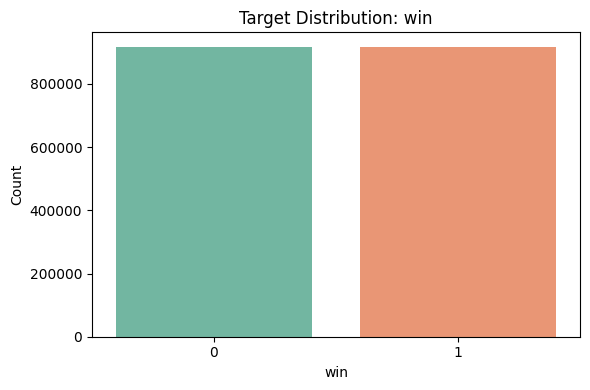

In [8]:
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=counts.index.astype(str), y=counts.values, hue=counts.index.astype(str), palette="Set2")
ax.set_title("Target Distribution: win")
ax.set_xlabel("win")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()


## 5. Univariate Analysis

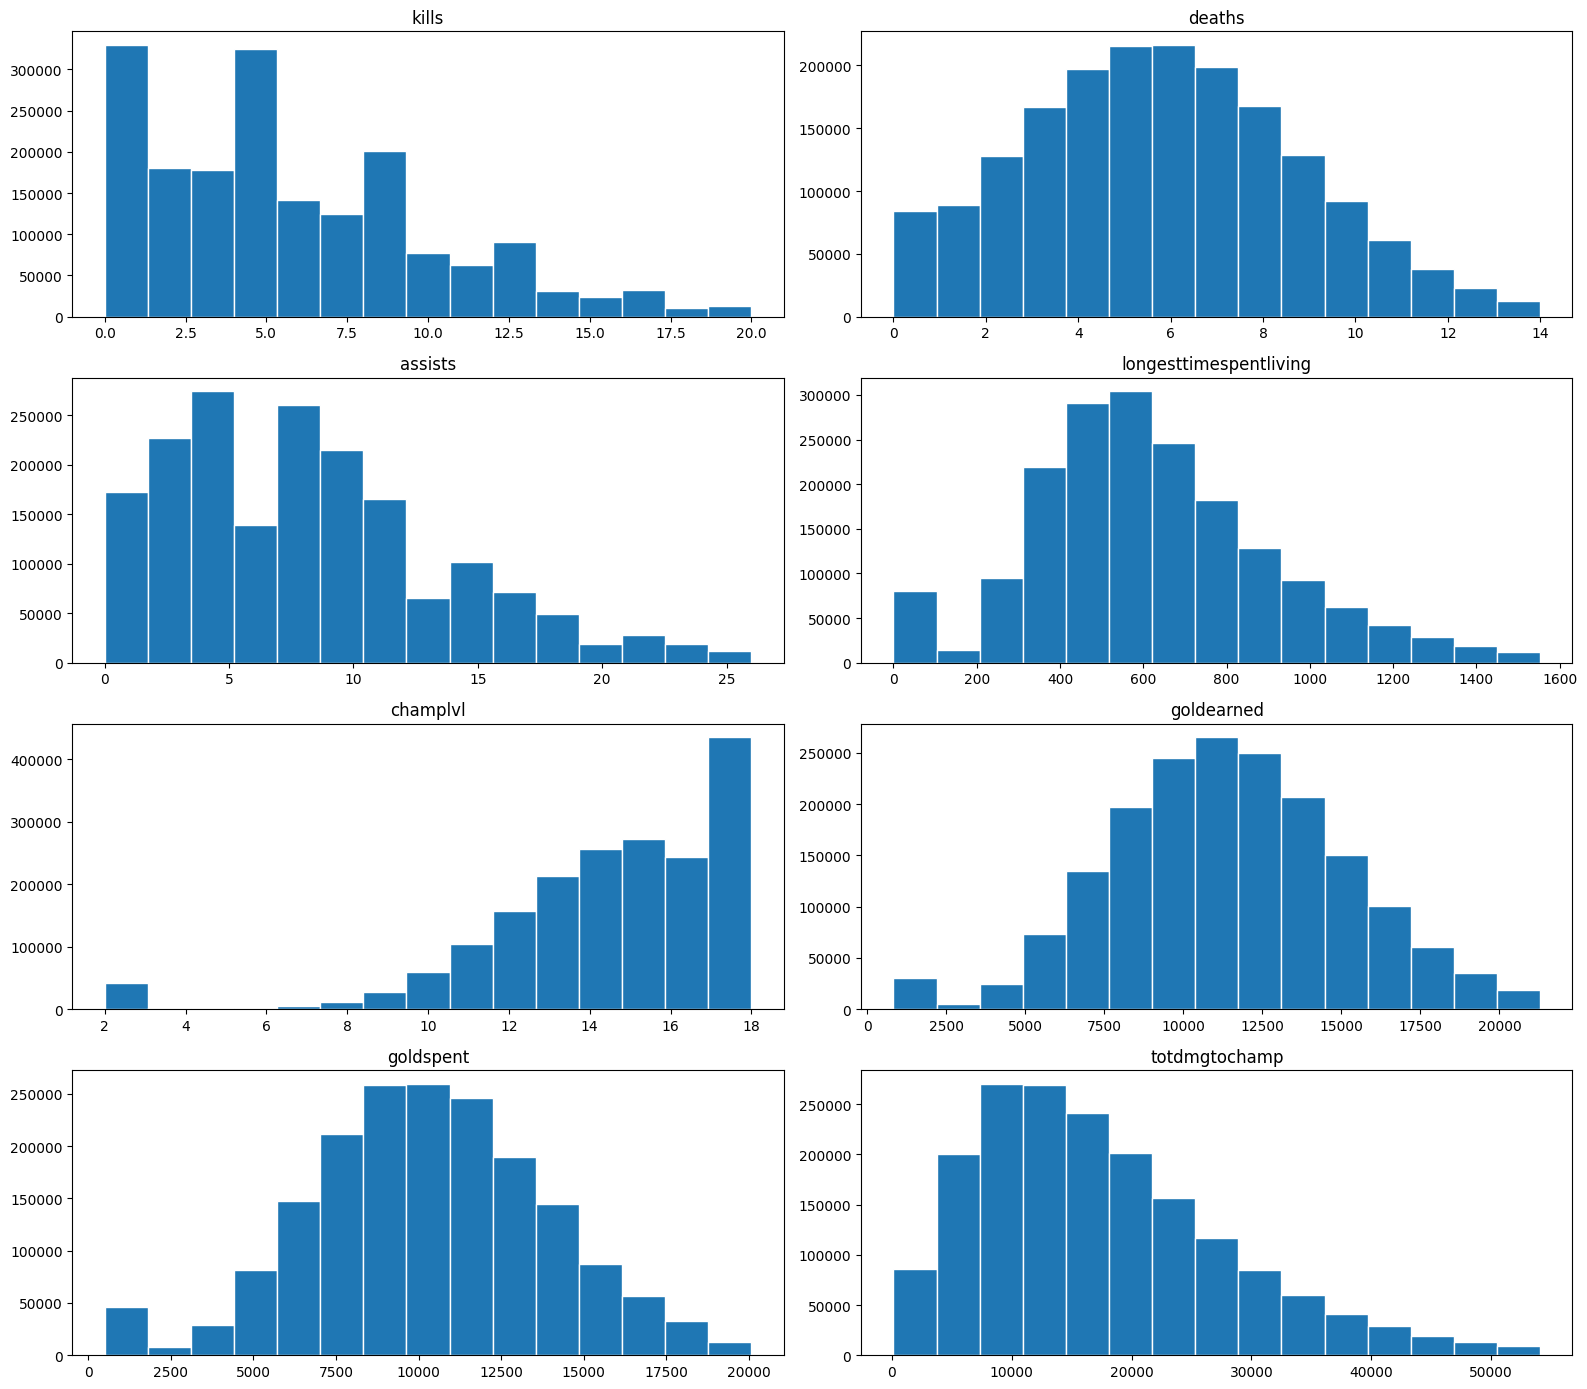

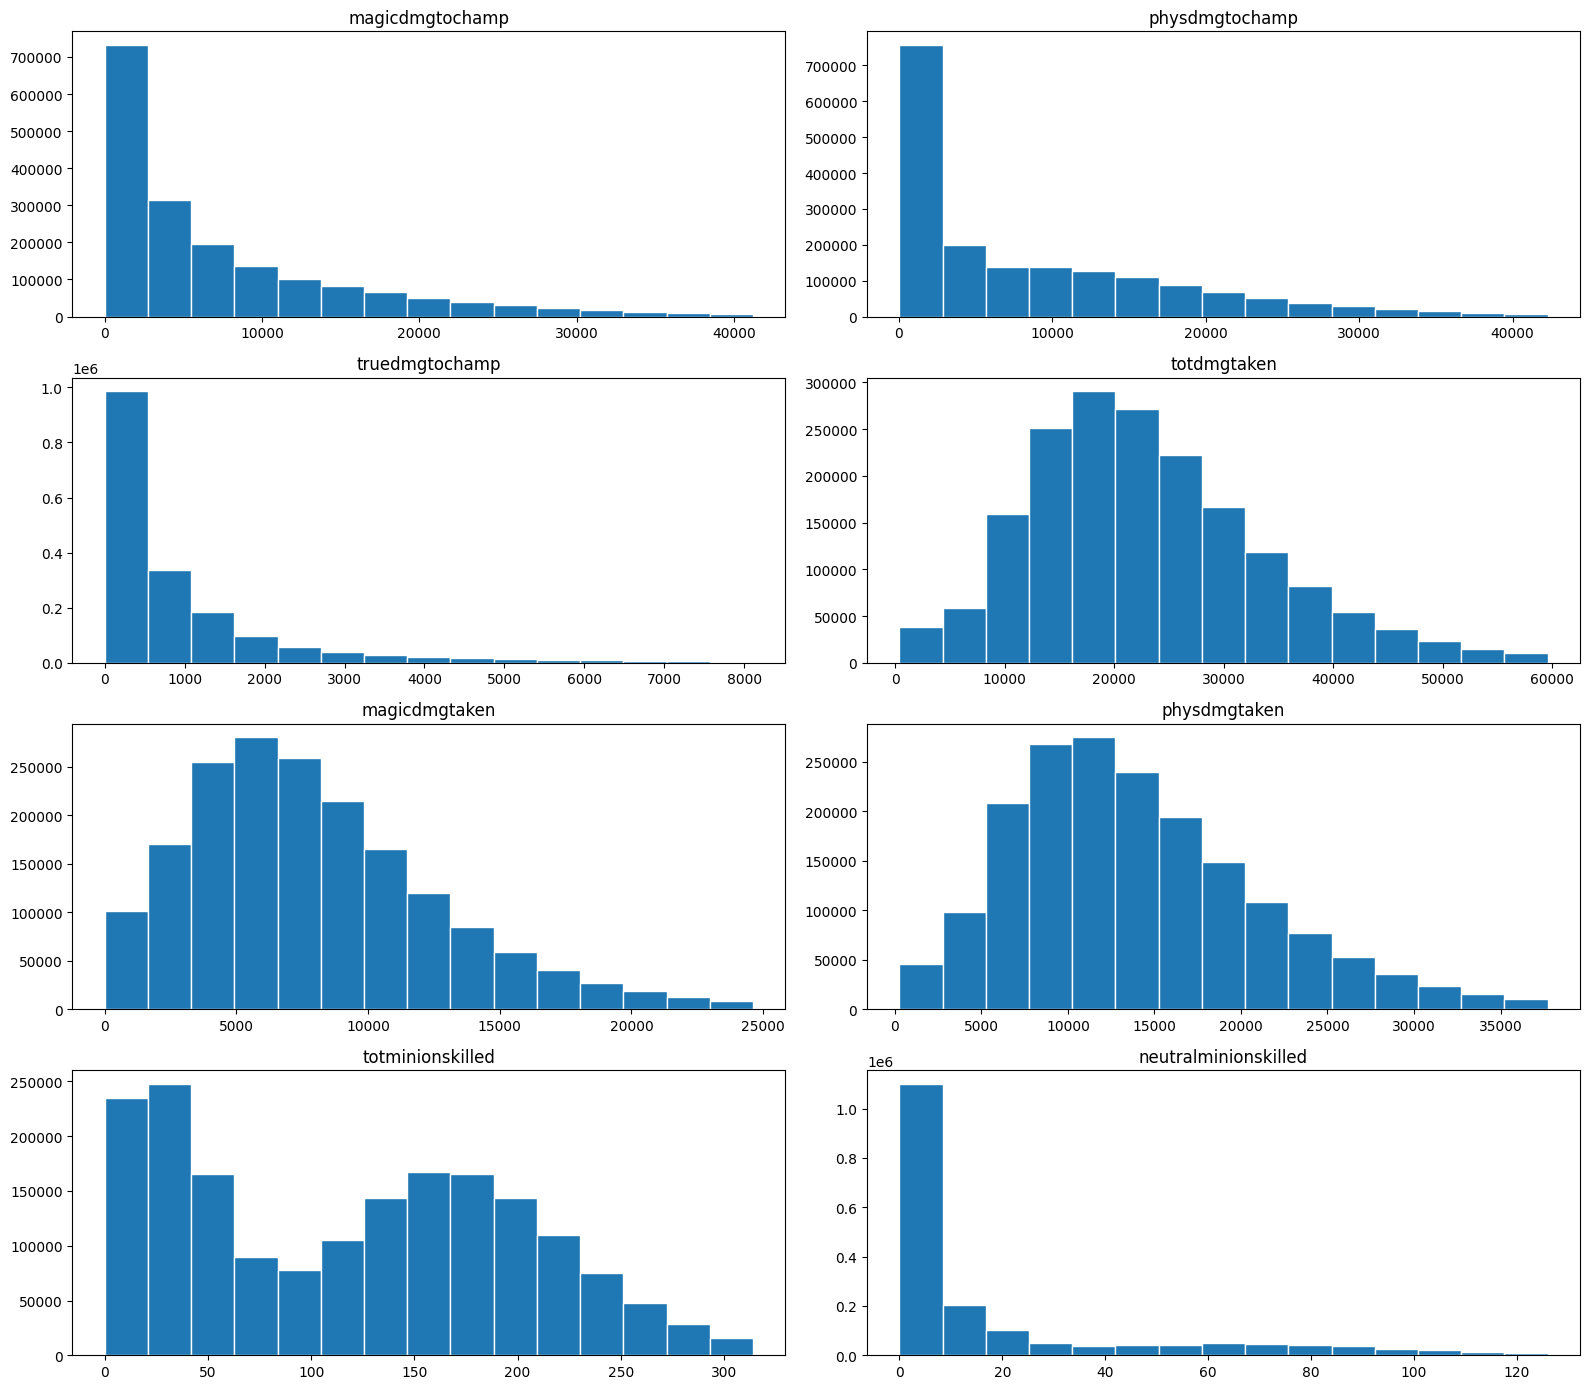

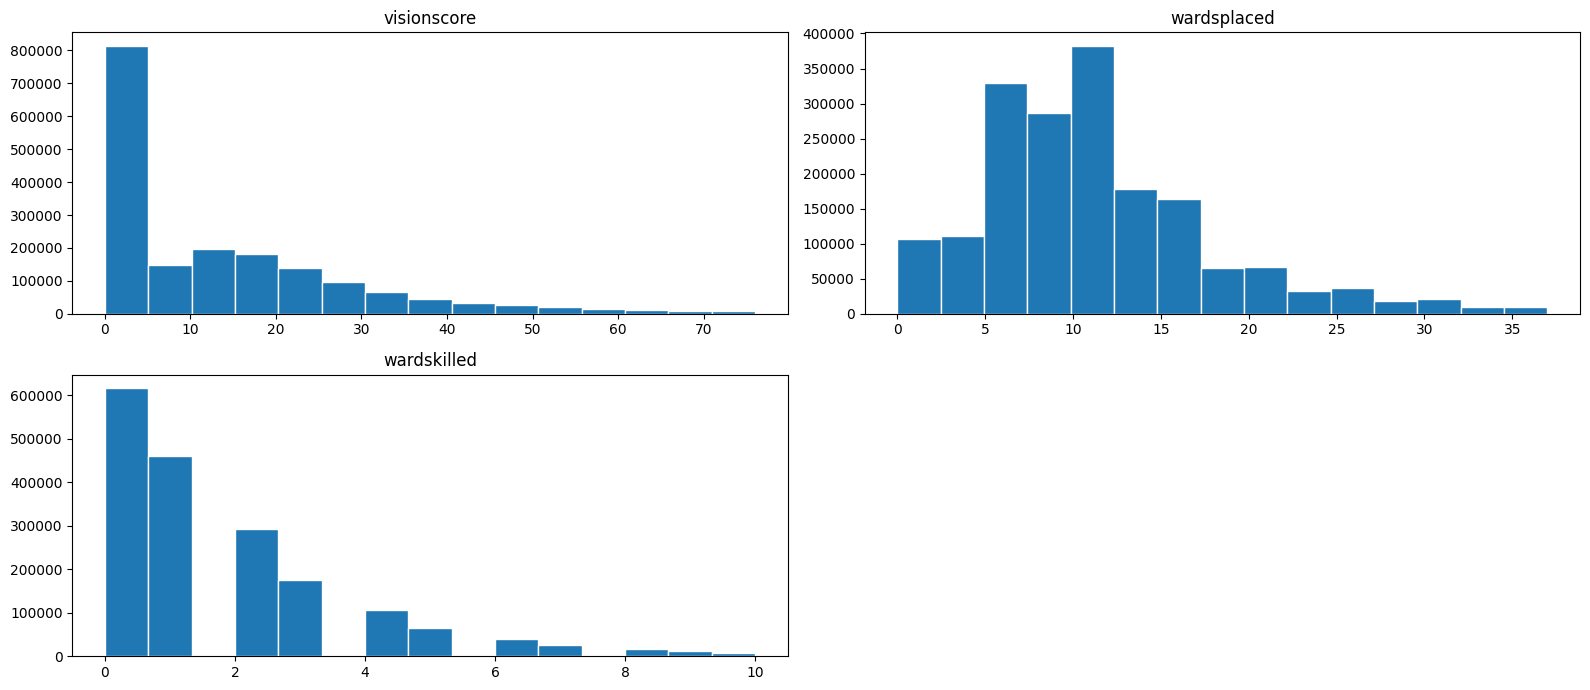

,count,mean,std,min,5%,25%,50%,75%,95%,max
kills,1834517.0,5.79,4.60,0.0,0.0,2.0,5.0,8.0,15.0,45.0
deaths,1834517.0,5.81,3.27,0.0,1.0,3.0,6.0,8.0,11.0,38.0
assists,1834517.0,8.32,5.92,0.0,1.0,4.0,7.0,12.0,20.0,57.0
longesttimespentliving,1834517.0,630.66,311.07,0.0,199.0,434.0,590.0,792.0,1202.0,3038.0
champlvl,1834517.0,14.22,3.12,1.0,9.0,13.0,15.0,16.0,18.0,18.0
goldearned,1834517.0,11415.60,4008.58,643.0,5302.0,8864.0,11350.0,13937.0,18039.0,40982.0
goldspent,1834517.0,10370.91,3869.36,0.0,4500.0,7950.0,10275.0,12750.0,16775.0,70255.0
totdmgtochamp,1834517.0,17702.96,11474.93,0.0,3358.0,9411.0,15553.0,23651.0,39384.0,152607.0
magicdmgtochamp,1834517.0,7750.30,9264.52,0.0,57.0,1335.0,4166.0,10940.0,26966.0,142469.0
physdmgtochamp,1834517.0,8951.45,9946.48,0.0,448.0,1452.0,4591.0,14043.0,28797.0,123871.0


In [16]:
core_features = [
    "kills",
    "deaths",
    "assists",
    "longesttimespentliving",
    "champlvl",
    "goldearned",
    "goldspent",
    "totdmgtochamp",
    "magicdmgtochamp",
    "physdmgtochamp",
    "truedmgtochamp",
    "totdmgtaken",
    "magicdmgtaken",
    "physdmgtaken",
    "totminionskilled",
    "neutralminionskilled",
    "visionscore",
    "wardsplaced",
    "wardskilled",
]

useful_cols = [c for c in core_features if c in stats_df.columns]

batch_size = 8
n_cols = 2

for start in range(0, len(useful_cols), batch_size):
    cols_batch = useful_cols[start : start + batch_size]
    n_rows = int(np.ceil(len(cols_batch) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols_batch):
        ax = axes[i]
        s = stats_df[col].dropna()

        q01, q99 = s.quantile([0.01, 0.99])
        s_plot = s[(s >= q01) & (s <= q99)]

        ax.hist(s_plot, bins=15, edgecolor="white")
               
        ax.set_title(col)
        ax.grid(False)

    for j in range(len(cols_batch), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

stats_df[useful_cols].describe(percentiles=[.05, .25, .5, .75, .95]).T.round(2)

## 6. Bivariate Analysis

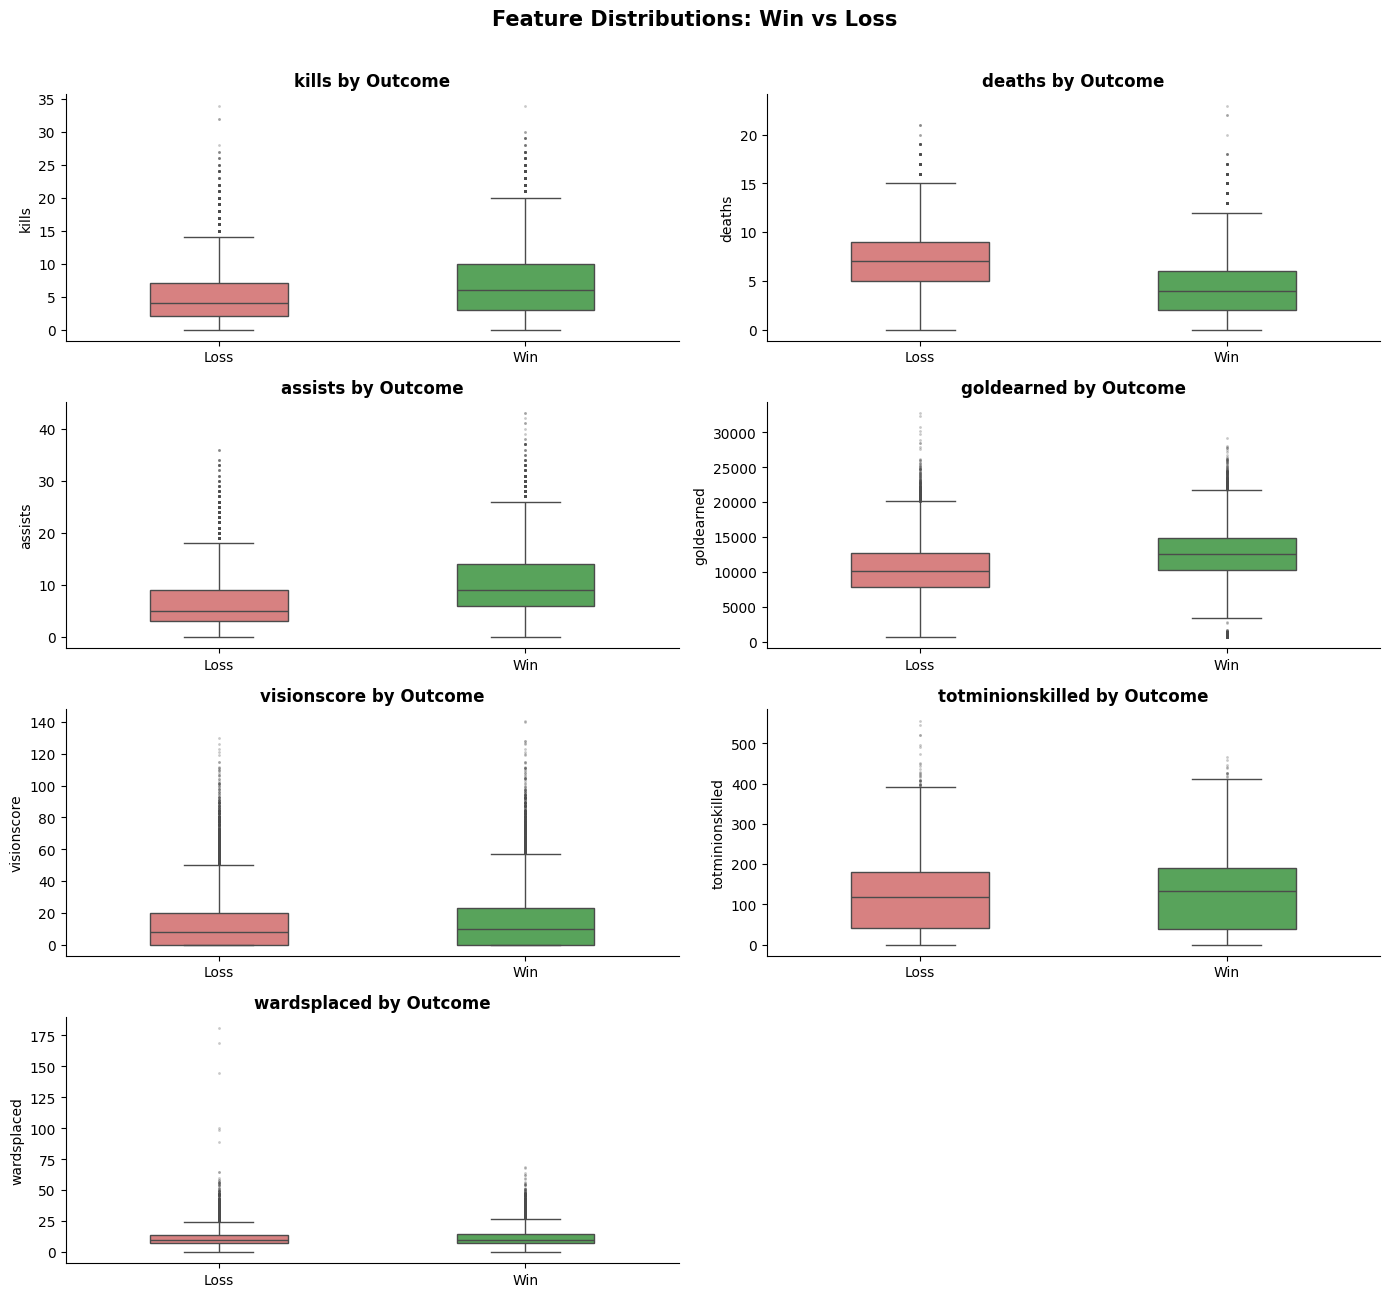

In [21]:
BOX_FEATURES = [
    "kills",
    "deaths",
    "assists",
    "goldearned",
    "totdmgtochamps",
    "visionscore",
    "totminionskilled",
    "wardsplaced",
]

GREEN = "#4CAF50"
RED = "#E57373"

box_cols = [c for c in BOX_FEATURES if c in stats_df.columns]

ncols = 2
nrows = 4

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, nrows * 3.2),
)
axes = np.array(axes).flatten()

sample = stats_df.sample(min(40000, len(stats_df)), random_state=42).copy()
sample["outcome"] = sample["win"].map({1: "Win", 0: "Loss"})

for i, col in enumerate(box_cols):
    ax = axes[i]
    sns.boxplot(
        data=sample,
        x="outcome",
        y=col,
        order=["Loss", "Win"],
        palette={"Win": GREEN, "Loss": RED},
        hue="outcome",
        width=0.45,
        flierprops=dict(marker=".", alpha=0.3, ms=2),
        linewidth=1,
        ax=ax,
    )
    ax.set_title(f"{col} by Outcome", fontweight="bold")
    ax.set_xlabel("")
    ax.spines[["top", "right"]].set_visible(False)

# Hide unused subplot slots
for j in range(len(box_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    "Feature Distributions: Win vs Loss",
    fontsize=15,
    fontweight="bold",
    y=1.01
)
plt.tight_layout()
plt.show()

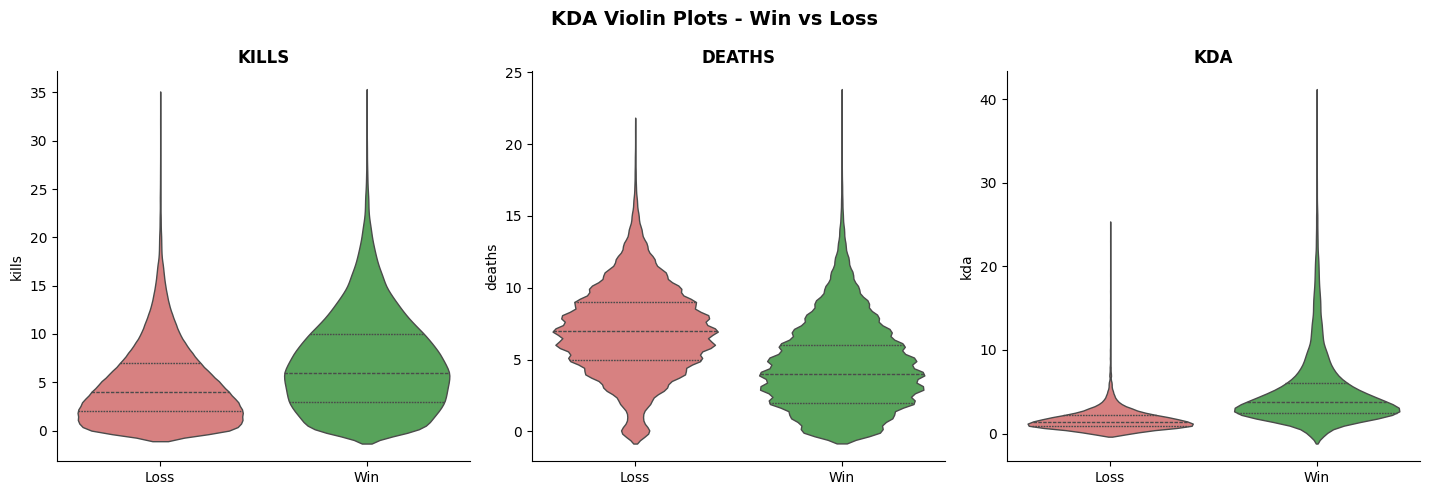

In [ ]:
# KDA analysis with violin plots (KDA = (kills + assists) / max(1, deaths))
# KDA is a famous metric

plot_cols = ["kills", "deaths"]
needed = {"kills", "assists", "deaths"}

sample = sample.copy()

sample["kda"] = (sample["kills"] + sample["assists"]) / sample["deaths"].clip(lower=1)
plot_cols.append("kda")

fig, axes = plt.subplots(1, len(plot_cols), figsize=(4.8 * len(plot_cols), 5))

for ax, col in zip(axes, plot_cols):
    sns.violinplot(
        data=sample,
        x="outcome",
        y=col,
        order=["Loss", "Win"],
        hue="outcome",
        palette={"Win": GREEN, "Loss": RED},
        legend=False,
        inner="quartile",
        linewidth=1,
        ax=ax,
    )
    ax.set_title(col.upper(), fontweight="bold")
    ax.set_xlabel("")
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("KDA Violin Plots Win vs Loss", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

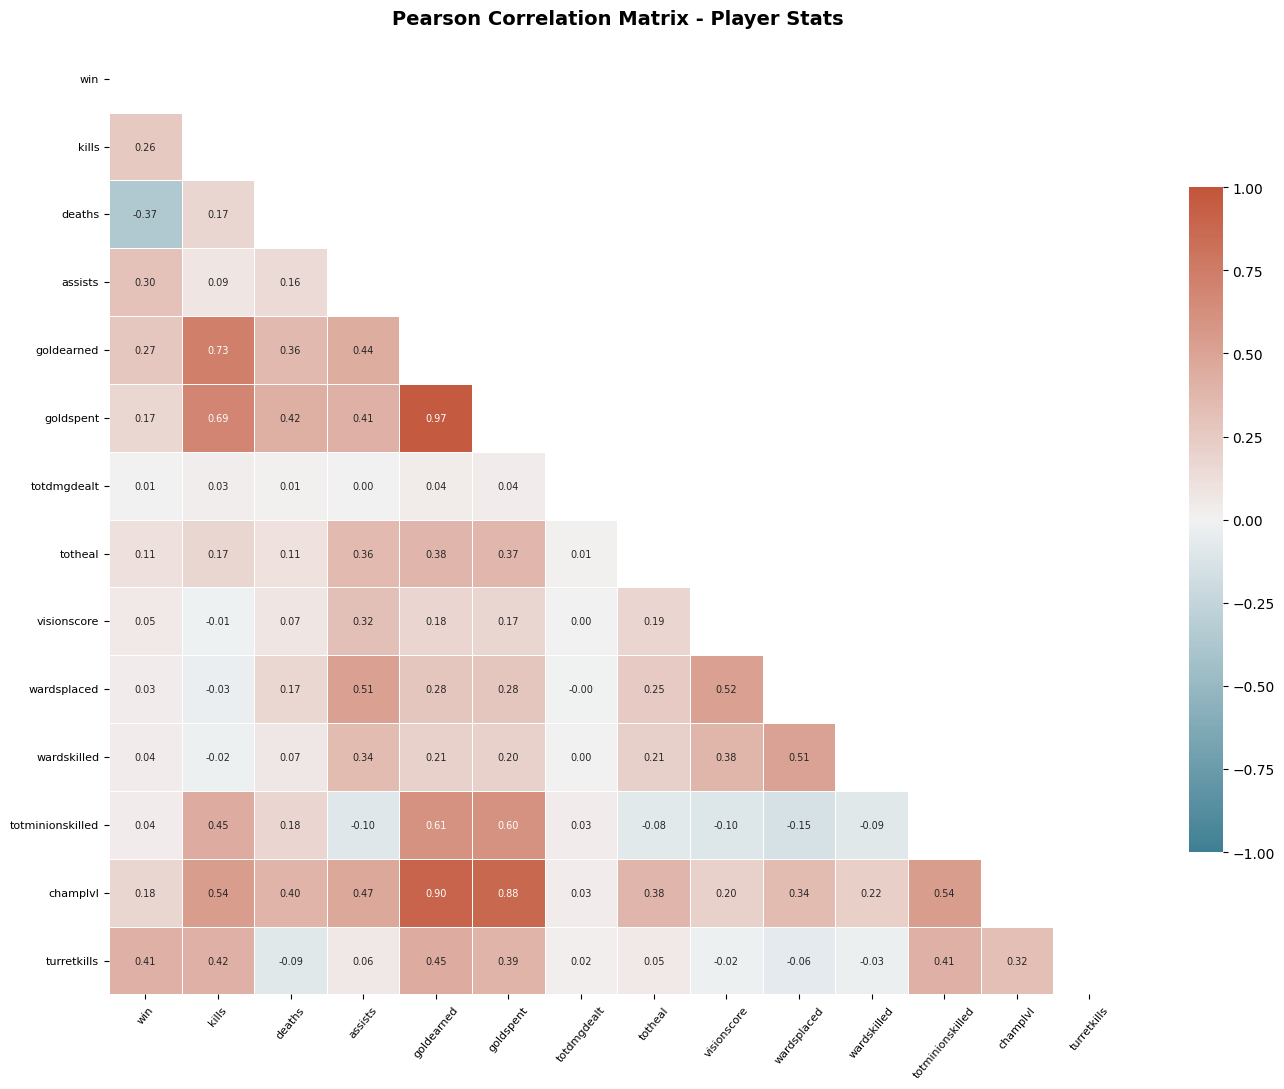

In [26]:
CORR_FEATURES = [
    "win",
    "kills",
    "deaths",
    "assists",
    "goldearned",
    "goldspent",
    "totdmgdealt",
    "totheal",
    "visionscore",
    "wardsplaced",
    "wardskilled",
    "totminionskilled",
    "champlvl",
    "turretkills",
]

corr = stats_df[CORR_FEATURES].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    linewidths=0.4,
    cmap=sns.diverging_palette(220, 20, as_cmap=True),
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
    annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7},
)

ax.set_title(
    "Pearson Correlation Matrix - Player Stats", fontsize=14, fontweight="bold", pad=15
)
ax.tick_params(axis="x", rotation=50, labelsize=8)
ax.tick_params(axis="y", rotation=0, labelsize=8)

plt.tight_layout()
plt.show()

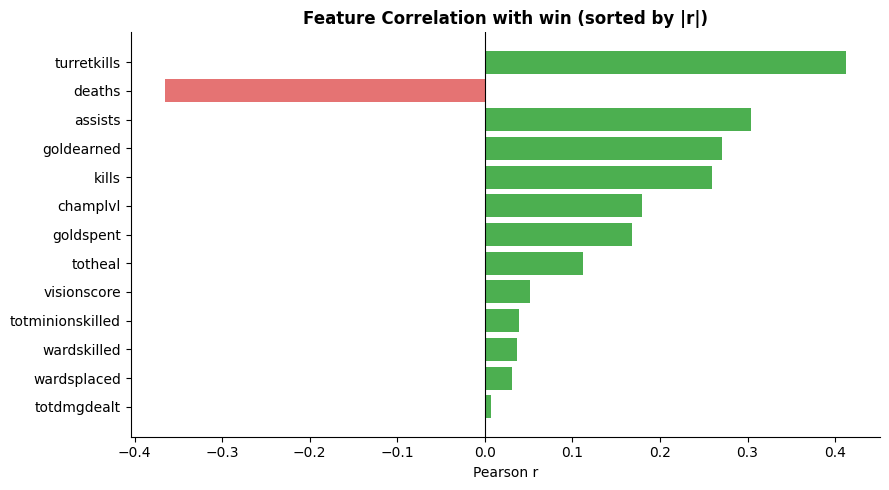

In [28]:
win_corr = corr["win"].drop("win").abs().sort_values(ascending=False)
win_corr_signed = corr["win"].drop("win").reindex(win_corr.index)

fig, ax = plt.subplots(figsize=(9, 5))

colors_bar = [GREEN if v > 0 else RED for v in win_corr_signed.values]
ax.barh(
    win_corr_signed.index[::-1],
    win_corr_signed.values[::-1],
    color=colors_bar[::-1],
    edgecolor="none",
)

ax.axvline(0, color="black", lw=0.8)
ax.set_title("Feature Correlation with win (sorted by |r|)", fontweight="bold")
ax.set_xlabel("Pearson r")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

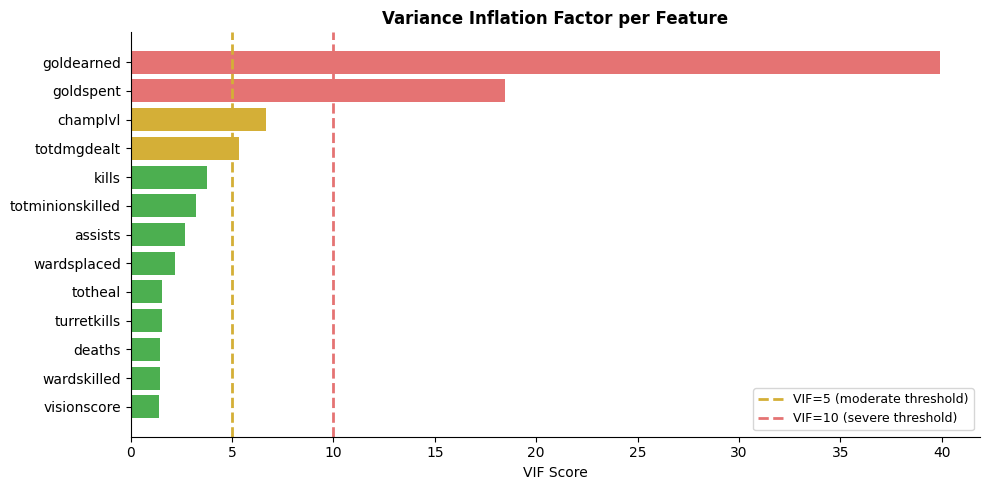

,Feature,VIF
3,goldearned,39.899566
4,goldspent,18.446443
11,champlvl,6.656239
5,totdmgdealt,5.338972
0,kills,3.738288
10,totminionskilled,3.199305
2,assists,2.666397
8,wardsplaced,2.202670
6,totheal,1.549988
12,turretkills,1.533032


In [33]:

GOLD = "#D4AF37"

VIF_FEATURES = [c for c in CORR_FEATURES if c != "win"]
vif_data = stats_df[VIF_FEATURES].dropna()
vif_sample = vif_data.sample(min(50000, len(vif_data)), random_state=42)

X_vif = add_constant(vif_sample)

vif_results = pd.DataFrame({
    "Feature": VIF_FEATURES,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(len(VIF_FEATURES))]
}).sort_values("VIF", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))

vif_colors = [
    RED if v > 10 else (GOLD if v > 5 else GREEN)
    for v in vif_results["VIF"]
]

ax.barh(
    vif_results["Feature"][::-1],
    vif_results["VIF"][::-1],
    color=vif_colors[::-1],
    edgecolor="none",
)
ax.axvline(5, color=GOLD, lw=2, ls="--", label="VIF=5 (moderate threshold)")
ax.axvline(10, color=RED, lw=2, ls="--", label="VIF=10 (severe threshold)")
ax.set_title("Variance Inflation Factor per Feature", fontweight="bold")
ax.set_xlabel("VIF Score")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

vif_results

## 8. Temporal Analysis

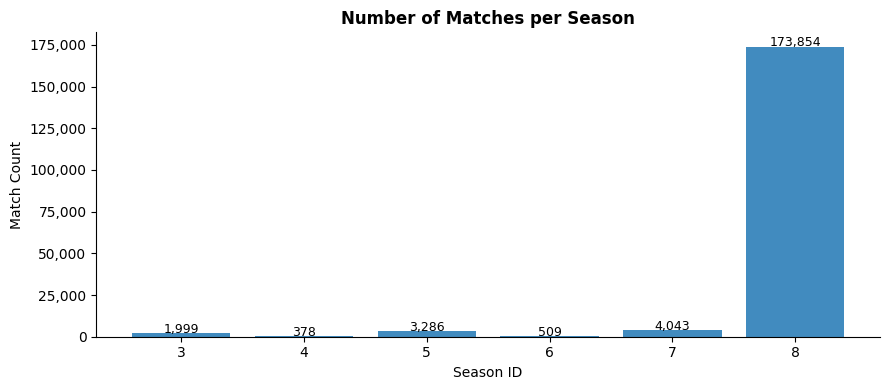

Season counts:
seasonid
3      1999
4       378
5      3286
6       509
7      4043
8    173854


In [36]:
season_counts = matches_df["seasonid"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    season_counts.index.astype(str),
    season_counts.values,
    edgecolor="none",
    alpha=0.85,
)

for i, v in enumerate(season_counts.values):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

ax.set_title("Number of Matches per Season", fontweight="bold")
ax.set_xlabel("Season ID")
ax.set_ylabel("Match Count")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Season counts:\n{season_counts.to_string()}")

## 9. Champion Analysis

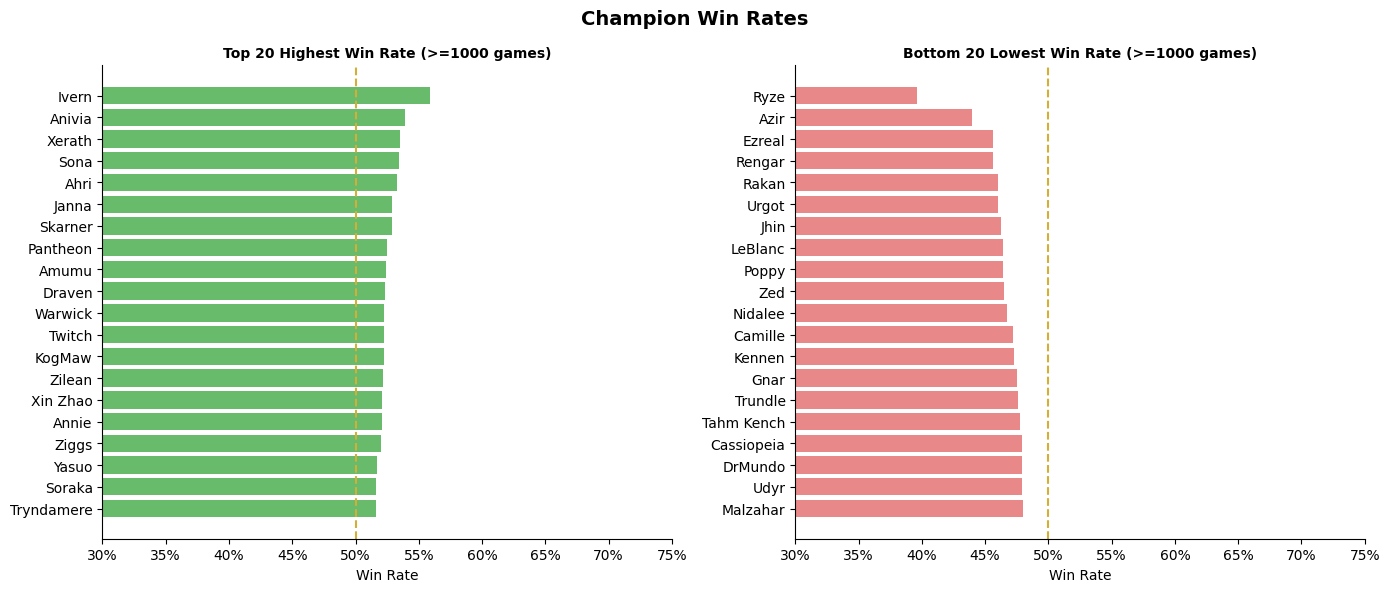

In [37]:
champ_map = champs_df.set_index("id")["name"].to_dict()

p_with_outcome = pd.merge(
    participants_df[["id", "championid"]],
    stats_df[["id", "win"]],
    on="id",
    how="inner",
)

champ_stats = (
    p_with_outcome.groupby("championid")
    .agg(games=("win", "count"), wins=("win", "sum"))
    .reset_index()
)

champ_stats["win_rate"] = champ_stats["wins"] / champ_stats["games"]
champ_stats = champ_stats[champ_stats["games"] >= 1000]
champ_stats["name"] = champ_stats["championid"].map(lambda x: champ_map.get(x, f"ID:{x}"))

top_wr = champ_stats.nlargest(20, "win_rate")
bottom_wr = champ_stats.nsmallest(20, "win_rate")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, title, color in [
    (ax1, top_wr, "Top 20 Highest Win Rate (>=1000 games)", GREEN),
    (ax2, bottom_wr, "Bottom 20 Lowest Win Rate (>=1000 games)", RED),
]:
    ax.barh(
        data["name"][::-1],
        data["win_rate"][::-1],
        color=color,
        edgecolor="none",
        alpha=0.85,
    )
    ax.axvline(0.5, color=GOLD, lw=1.5, ls="--")
    ax.set_title(title, fontweight="bold", fontsize=10)
    ax.set_xlabel("Win Rate")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.set_xlim(0.3, 0.75)
    ax.spines[["top", "right"]].set_visible(False)

plt.suptitle("Champion Win Rates", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Findings

- 184,070 matches
- participants.csv links players to matches
- stats1.csv and stats2.csv are the same schema (row-joined)
- Class ratio is 1, no modification needed in this part
- Check correlation analysis above for strongest correlations with win.
- Multicollinearity is a problem, VIF analysis shows the following columns needs to be fixed (maybe removed or handled using dim reduction or regularization):
  - goldearned: 41.41
  - goldspent: 18.91
  - champlvl: 6.73
  - totdmgdealt: 5.39
- goldearned and goldspent have perfect collinearity r=0.99
- kills and goldearned have very high correlation
- Champion win rate shows that there are some champions that have much higher win rates than others.
- champion identitiy should be encoded.
- Things to explore in feature engineering:
  - gold difference between teams
  - vision score adds predictive value
  - KDA
  - First blood/tower can be good predictors for winner
